# Directional Command Recognition in Sinhala-English Speech Using Whisper ASR + FastText Semantic Similarity

A robust pipeline for recognizing directional commands (forward, backward, left, right, stop) in code-mixed Sinhala-English speech using state-of-the-art ASR and semantic embedding models.


![Pipeline](../pipeline.png)

### Project Overview

### 🛠 System Architecture & Model Pipeline

#### 1. Pipeline Visualization
Below is a descriptive overview of the end-to-end pipeline for directional command recognition from raw audio:

1. **Audio Processing:**
   - The system begins with raw audio input, which undergoes preprocessing steps such as silence trimming and volume normalization to ensure consistent quality.
2. **Feature Extraction:**
   - The preprocessed audio is transcribed into text using the Whisper ASR engine, which is fine-tuned for Sinhala-English code-mixed speech.
   - The resulting text is then passed through the MiniLM-L12-v2 model, which generates a dense semantic embedding that captures the multilingual meaning of the command.
3. **Classification:**
   - The semantic embedding is fed into a lightweight PyTorch MLP classifier. This neural network processes the embedding through several layers, applying non-linear transformations and regularization, to predict the most likely directional command (Forward, Backward, Left, Right, or Stop).

This pipeline ensures that the system can robustly handle noisy, code-mixed speech and accurately map spoken commands to actionable directions for downstream applications.

#### 2. Core Model Concepts (Layer Format)

| **Component** | **Model/Layer Type** | **Key Function** |
| :--- | :--- | :--- |
| **ASR Engine** | **Whisper-Small** | Converts audio signals into text using a Transformer-based encoder-decoder architecture, enabling robust transcription of code-mixed Sinhala-English speech. |
| **Embedding** | **MiniLM-L12-v2** | Transforms transcribed text into a 384-dimensional semantic vector, capturing the intent and meaning of the command across languages. |
| **Classifier** | **Input Layer** | Reduces the high-dimensional semantic vector to a lower-dimensional space (128 units) and applies a ReLU activation for non-linearity. |
| **Classifier** | **Dropout** | Randomly deactivates 30% of neurons during training to prevent overfitting and improve generalization. |
| **Classifier** | **Hidden Layer** | Further compresses features to 64 units with ReLU activation, learning complex relationships between command types. |
| **Classifier** | **Output Layer** | Maps the learned features to one of the five directional command classes, producing the final prediction. |


### Environment Setup

In [1]:
!pip install transformers datasets jiwer torchaudio librosa sentence-transformers tqdm matplotlib seaborn scikit-learn soundfile optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 125.7 MB/s eta 0:00:00


In [2]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import librosa.display
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## step 1: Data Acquisition & Preprocessing

*The foundation of the pipeline. Poor audio quality will cascade into Whisper and ruin the embeddings.*

1. **Dataset Compilation:** Gather `.wav` files for the 5 directional classes (forward, backward, left, right, stop) in both English, Sinhala, and code-mixed formats.
2. 💡 **Crucial Addition - Train/Val/Test Split:** You **must** split your raw audio files into Training (e.g., 70%), Validation (15%), and Test (15%) sets *before* doing any feature extraction. This prevents "data leakage" (accidentally testing on data the model has seen).
3. **Silence Trimming:** Remove dead air at the beginning and end of the audio clips.
4. 💡 **Crucial Addition - Robust Audio Cleaning:**
    - **DC Offset Removal:** Center the waveform at zero to prevent random character generation.
    - **RMS Normalization:** Use Root Mean Square (RMS) instead of Peak Normalization to handle fragile mic-clicks.
    - **Short Audio Padding:** Ensure clips are at least 1 second long to prevent model "panic" and repeating characters.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 1.1 Dataset Compilation
import os

# Robust path configuration
if os.path.exists("/content/drive/MyDrive/2nd Year Research Data/Directions"):
    ROOT_DIR = "/content/drive/MyDrive/2nd Year Research Data/Directions"
else:
    # Assume local workspace structure
    # If running from 'files/' directory, root is one level up
    ROOT_DIR = ".." if os.path.basename(os.getcwd()) == "files" else "."

DATA_DIR = ROOT_DIR  # Corrected: Assume labels are directly under ROOT_DIR
LABELS = ["backward", "forward", "left", "right", "stop"]

data = []
for label in LABELS:
    path = os.path.join(DATA_DIR, label)
    if not os.path.exists(path):
        print(f"Warning: Path {path} does not exist.")
        continue
    files = glob.glob(os.path.join(path, "*.wav"))
    for f in files:
        data.append({"path": f, "label": label})

df = pd.DataFrame(data)
print(f"Total samples found: {len(df)}")

Total samples found: 380


### 1.3 Silence Trimming & Volume Normalization

In [5]:
import soundfile as sf
import os

def preprocess_audio(file_path):
    """Applies trimming and normalization to a single audio file."""
    y, sr = librosa.load(file_path, sr=16000)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    y_norm = librosa.util.normalize(y_trimmed)
    return y_norm, sr

if not df.empty:
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
    os.makedirs(preprocessed_audio_dir, exist_ok=True)

    processed_paths = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing Audio"):
        filename = os.path.basename(row['path'])
        label_subdir = os.path.join(preprocessed_audio_dir, row['label'])
        os.makedirs(label_subdir, exist_ok=True)
        new_path = os.path.join(label_subdir, filename)

        # Check if the file already exists to avoid redundant processing
        if os.path.exists(new_path):
            processed_paths.append(new_path)
        else:
            try:
                y_proc, sr = preprocess_audio(row['path'])
                sf.write(new_path, y_proc, sr)
                processed_paths.append(new_path)
            except Exception as e:
                print(f" [Error] Failed to process {row['path']}: {e}")
                processed_paths.append(row['path']) # Fallback to original path if processing fails

    df['path'] = processed_paths
    print(f"Preprocessed paths updated for {len(df)} samples.")

Preprocessing Audio:   0%|          | 0/380 [00:00<?, ?it/s]

Preprocessed paths updated for 380 samples.


## step 2: Exploratory Data Analysis (EDA)

*Proving you understand the data before modeling it.*

1. **Class Imbalance Check:** Generate histograms to prove each of the 5 directions has roughly the same number of samples.
2. **Acoustic Visualization:** Generate and display Mel-spectrograms for a few samples to show the acoustic differences between English and Sinhala commands.
3. 💡 **Crucial Addition - Audio Length Distribution:** Plot a histogram of audio durations (e.g., most clips are 1.5 to 2.5 seconds). This justifies your real-time processing window later.

/tmp/ipykernel_3486/2178915580.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x='label', palette='viridis')


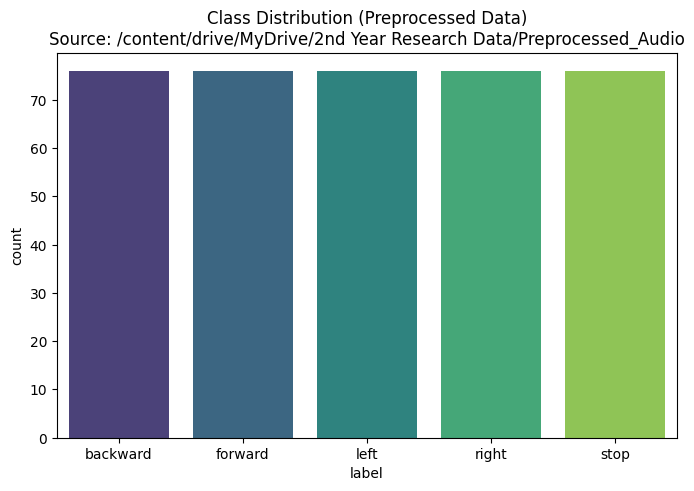

Total preprocessed samples found: 380


In [6]:
import glob

# Ensure we check the preprocessed directory
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Re-scan the preprocessed directory to ensure the plot reflects the actual processed files
preprocessed_data = []
for label in LABELS:
    label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(label_path):
        files = glob.glob(os.path.join(label_path, "*.wav"))
        for f in files:
            preprocessed_data.append({"path": f, "label": label})

if preprocessed_data:
    df_plot = pd.DataFrame(preprocessed_data)
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_plot, x='label', palette='viridis')
    plt.title(f"Class Distribution (Preprocessed Data)\nSource: {preprocessed_audio_dir}")
    plt.show()
    print(f"Total preprocessed samples found: {len(df_plot)}")
else:
    print(f"[Error] No preprocessed audio found in {preprocessed_audio_dir}. Please run the preprocessing step first.")

Calculating durations... this may take a moment.


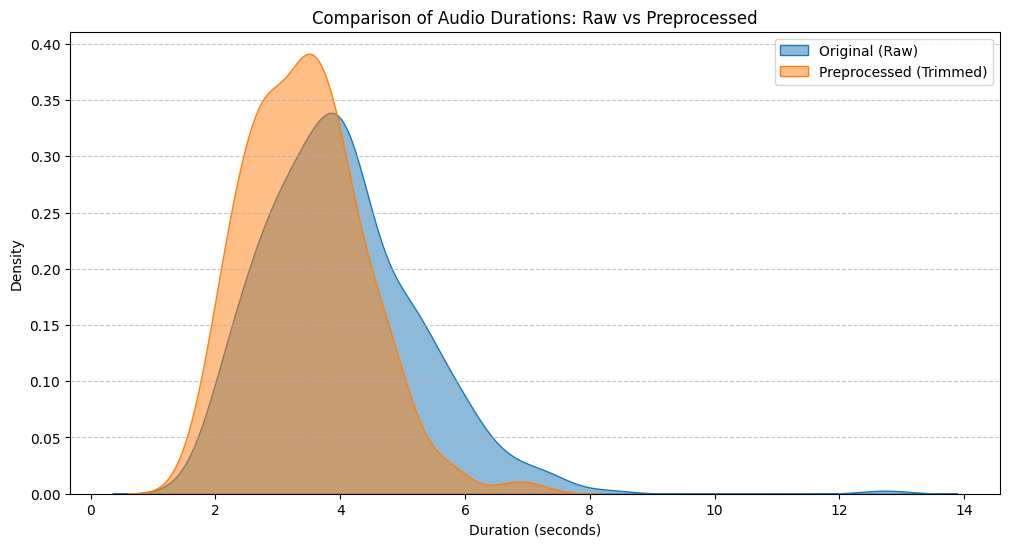


--- Duration Statistics Comparison ---
       Metric  Raw Data (s)  Preprocessed (s)
Mean Duration      4.017678          3.440573
 Min Duration      1.509250          1.477250
 Max Duration     12.736000          7.232000
Total Samples    380.000000        379.000000

Average reduction per file: 0.58s (due to silence trimming)


In [7]:
# 2.2 Audio Length Distribution Comparison (Before vs After Preprocessing)
import os
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import numpy as np

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"
LABELS = ["backward", "forward", "left", "right", "stop"]

def get_durations(base_dir):
    durations = []
    for label in LABELS:
        label_path = os.path.join(base_dir, label)
        if os.path.exists(label_path):
            files = glob.glob(os.path.join(label_path, "*.wav"))
            for f in files:
                try:
                    dur = librosa.get_duration(path=f)
                    durations.append(dur)
                except:
                    continue
    return durations

print("Calculating durations... this may take a moment.")
raw_durations = get_durations(raw_audio_dir)
proc_durations = get_durations(preprocessed_audio_dir)

if raw_durations and proc_durations:
    plt.figure(figsize=(12, 6))

    # Plotting comparison
    sns.kdeplot(raw_durations, label="Original (Raw)", fill=True, alpha=0.5)
    sns.kdeplot(proc_durations, label="Preprocessed (Trimmed)", fill=True, alpha=0.5)

    plt.title("Comparison of Audio Durations: Raw vs Preprocessed")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Display Stats
    stats_df = pd.DataFrame({
        "Metric": ["Mean Duration", "Min Duration", "Max Duration", "Total Samples"],
        "Raw Data (s)": [np.mean(raw_durations), np.min(raw_durations), np.max(raw_durations), len(raw_durations)],
        "Preprocessed (s)": [np.mean(proc_durations), np.min(proc_durations), np.max(proc_durations), len(proc_durations)]
    })

    print("\n--- Duration Statistics Comparison ---")
    print(stats_df.to_string(index=False))

    reduction = np.mean(raw_durations) - np.mean(proc_durations)
    print(f"\nAverage reduction per file: {reduction:.2f}s (due to silence trimming)")
else:
    print("[Error] Could not find audio in one of the directories. Please check your Drive paths.")

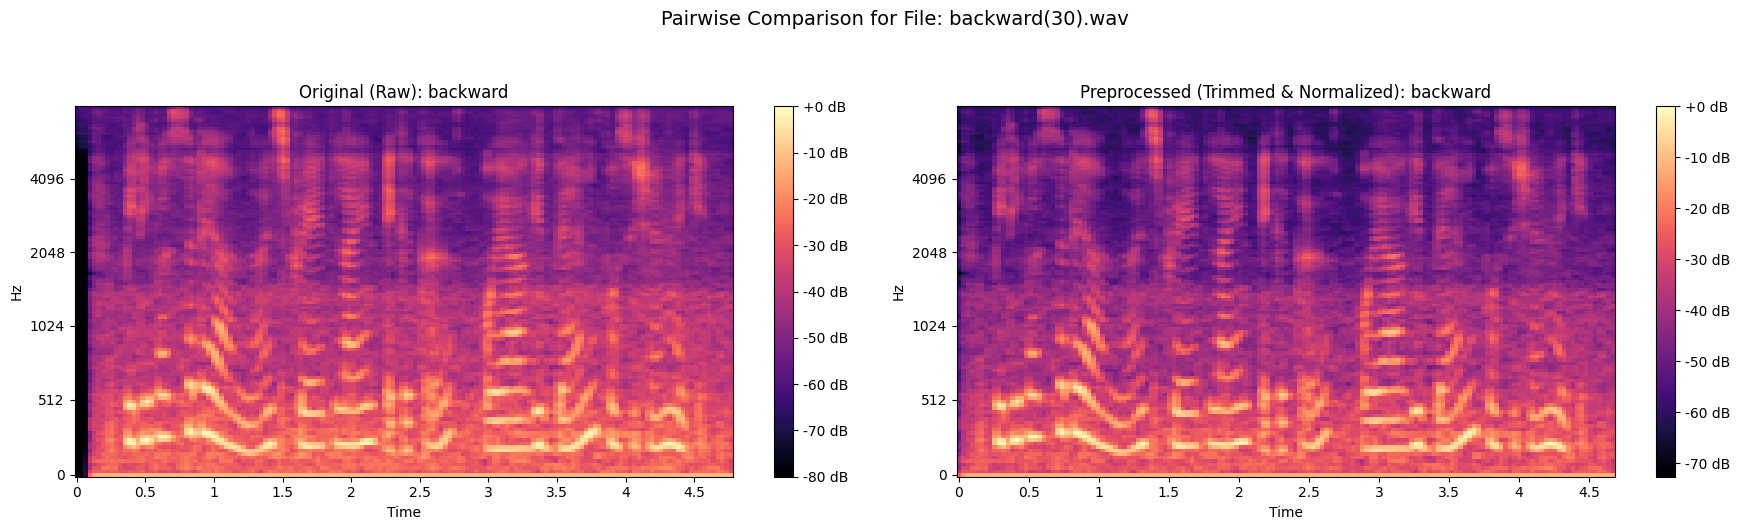

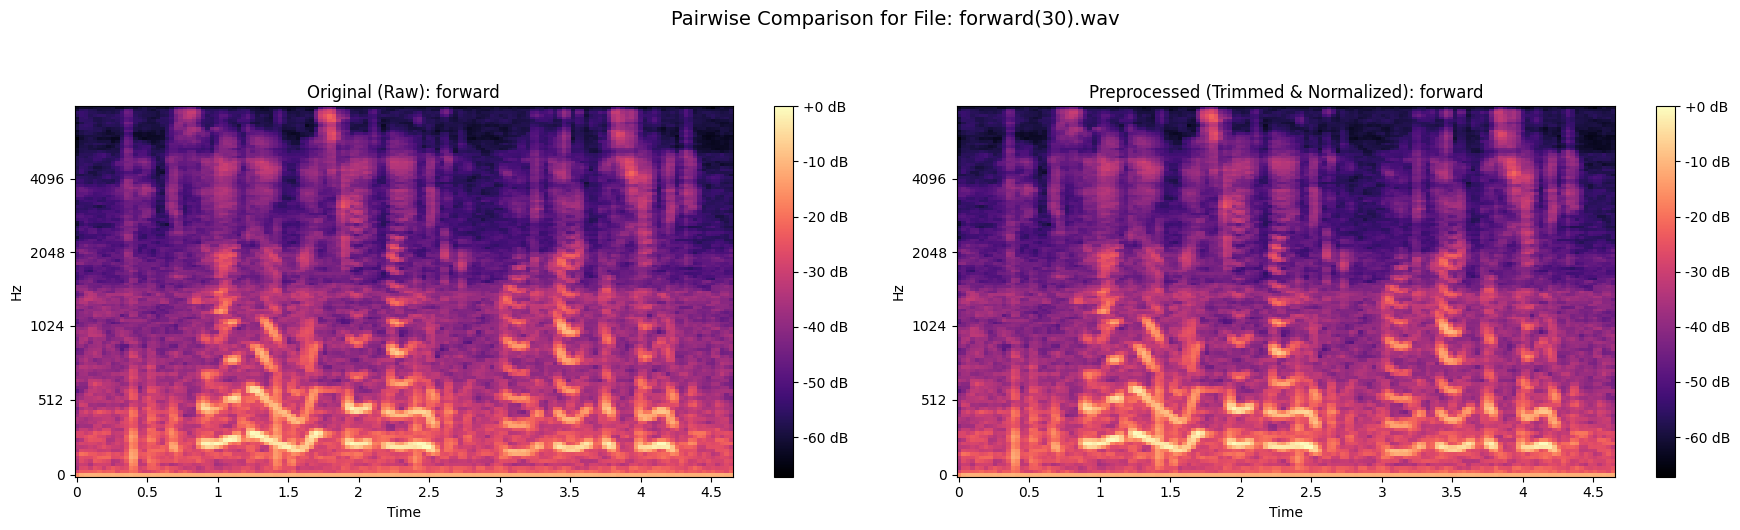

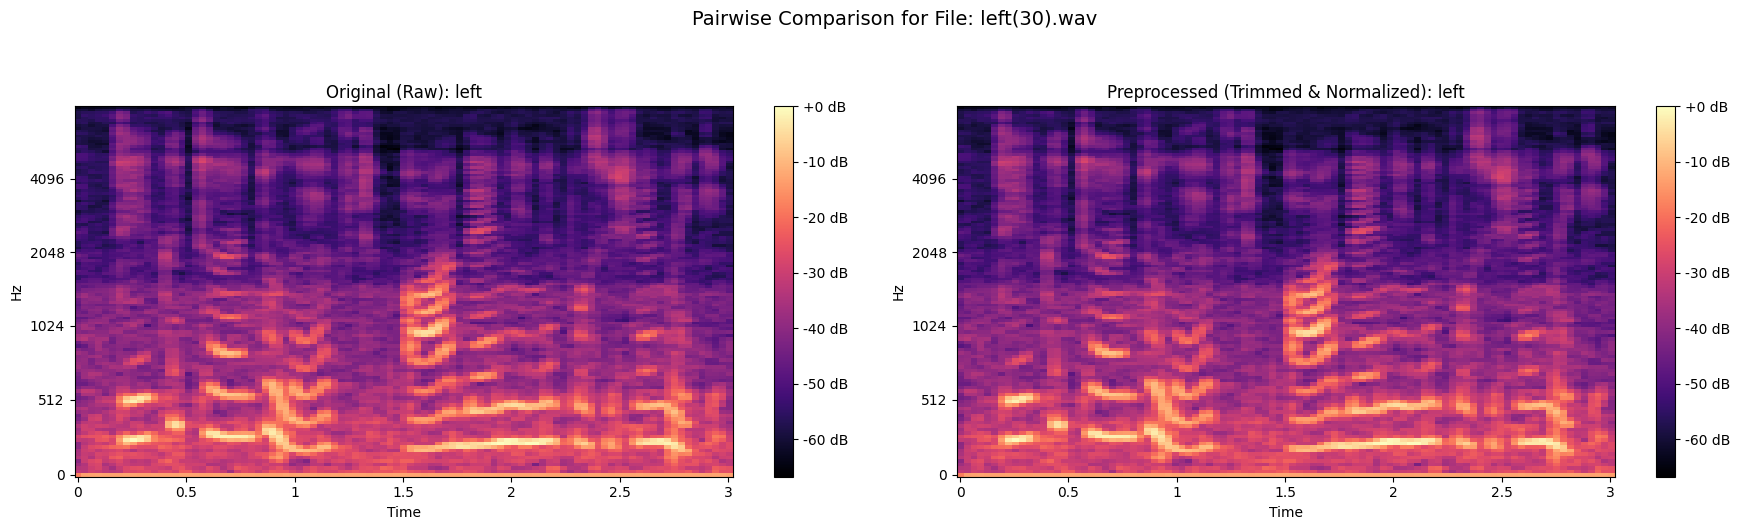

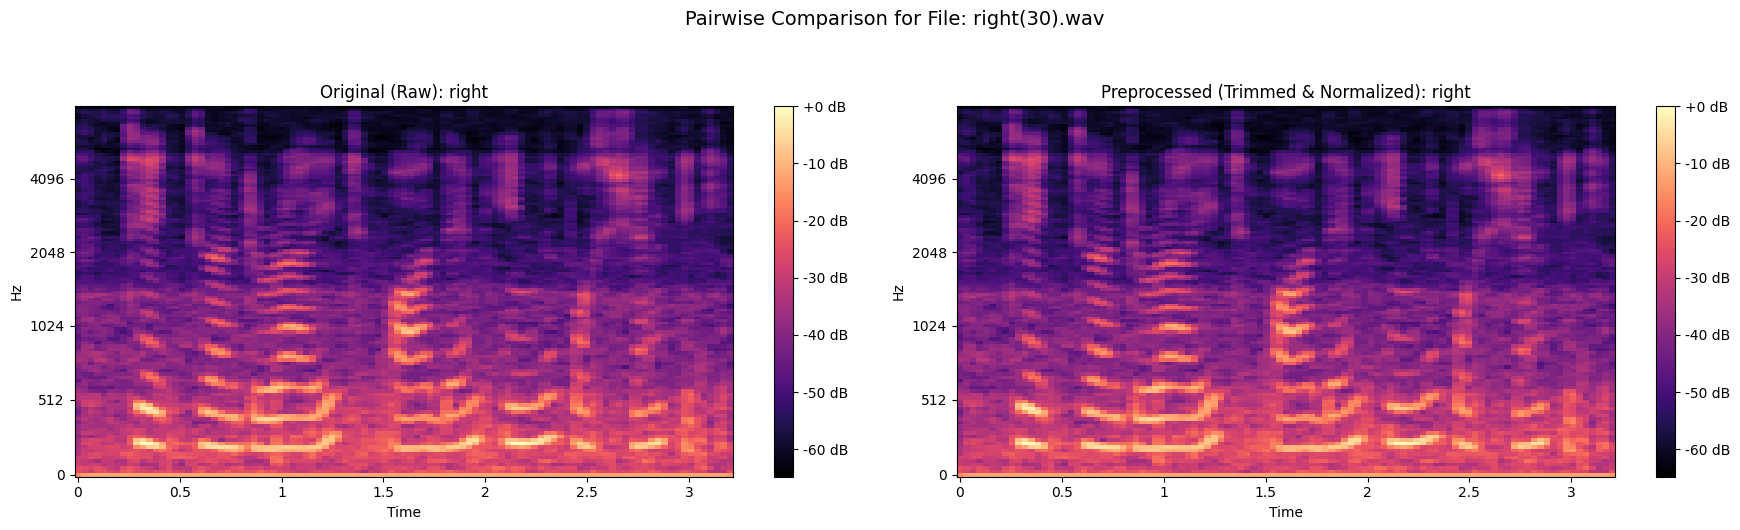

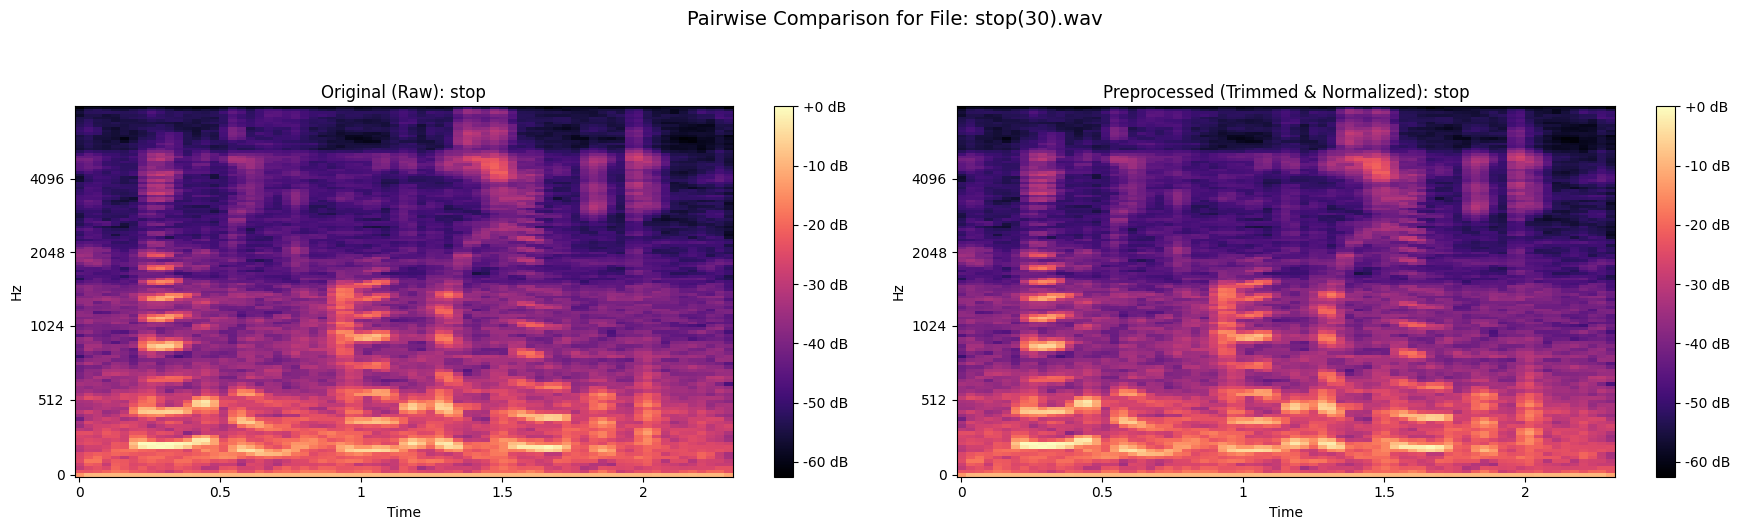

In [8]:
# 2.3 Acoustic Visualization: Before vs After Preprocessing (Pairwise Comparison)
import glob
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def compare_mel_spectrograms(raw_path, proc_path, label):
    # Adjusted to 1 row and 2 columns for horizontal positioning
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Raw Plot (Left)
    y_raw, sr = librosa.load(raw_path, sr=16000)
    S_raw = librosa.feature.melspectrogram(y=y_raw, sr=sr, n_mels=128)
    S_dB_raw = librosa.power_to_db(S_raw, ref=np.max)
    img1 = librosa.display.specshow(S_dB_raw, x_axis='time', y_axis='mel', sr=sr, ax=axes[0])
    axes[0].set_title(f"Original (Raw): {label}")
    fig.colorbar(img1, ax=axes[0], format='%+02.0f dB')

    # Preprocessed Plot (Right)
    y_proc, sr = librosa.load(proc_path, sr=16000)
    S_proc = librosa.feature.melspectrogram(y=y_proc, sr=sr, n_mels=128)
    S_dB_proc = librosa.power_to_db(S_proc, ref=np.max)
    img2 = librosa.display.specshow(S_dB_proc, x_axis='time', y_axis='mel', sr=sr, ax=axes[1])
    axes[1].set_title(f"Preprocessed (Trimmed & Normalized): {label}")
    fig.colorbar(img2, ax=axes[1], format='%+02.0f dB')

    plt.suptitle(f"Pairwise Comparison for File: {os.path.basename(raw_path)}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

# Visualize one sample for each label side-by-side
for label in LABELS:
    proc_label_path = os.path.join(preprocessed_audio_dir, label)
    if os.path.exists(proc_label_path):
        proc_files = glob.glob(os.path.join(proc_label_path, "*.wav"))
        if proc_files:
            filename = os.path.basename(proc_files[0])
            raw_file_path = os.path.join(raw_audio_dir, label, filename)

            if os.path.exists(raw_file_path):
                compare_mel_spectrograms(raw_file_path, proc_files[0], label)
            else:
                print(f"[Warn] Could not find raw counterpart for {filename}")

In [9]:
# 1.2 Train/Val/Test Split
if not df.empty:
    # Ensure we are using the preprocessed directory
    preprocessed_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio"

    # Update the dataframe paths to point to the preprocessed versions if they exist
    def update_to_preprocessed_path(row):
        filename = os.path.basename(row['path'])
        new_path = os.path.join(preprocessed_audio_dir, row['label'], filename)
        return new_path if os.path.exists(new_path) else row['path']

    df['path'] = df.apply(update_to_preprocessed_path, axis=1)

    # Perform the split on the updated paths
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df['label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

    output_dir = "/content/drive/MyDrive/2nd Year Research Data/Data"
    os.makedirs(output_dir, exist_ok=True)
    train_df.to_csv(os.path.join(output_dir, 'train_df.csv'), index=False)
    val_df.to_csv(os.path.join(output_dir, 'val_df.csv'), index=False)
    test_df.to_csv(os.path.join(output_dir, 'test_df.csv'), index=False)

    print(f"Split complete using data from: {preprocessed_audio_dir}")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Split complete using data from: /content/drive/MyDrive/2nd Year Research Data/Preprocessed_Audio
Train: 266, Val: 57, Test: 57


## step 3: Feature Extraction (The NLP Bridge)

*Converting raw audio into multi-lingual mathematical representations.*

1. **ASR Transcription:** Pass the preprocessed audio through `whisper-small-Sinhala-Fine_Tune`. Store the raw text output.
2. **Semantic Embedding:** Pass the text transcripts through `paraphrase-multilingual-MiniLM-L12-v2` to generate 384-dimensional vectors.
3. **Tensor Conversion:** Convert the NumPy arrays of vectors into PyTorch Tensors.
4. 💡 **Crucial Addition - Vector Caching:** Save these final tensors to your hard drive using `torch.save(tensor, 'train_tensors.pt')`. This way, as you tweak your Neural Network in the next phase, you don't have to wait for Whisper to transcribe the audio every single time you run the script.
5. 💡 **Crucial Addition - t-SNE / PCA Visualization:** Before training the neural network, reduce your 384D vectors to 2D using t-SNE and plot them on a scatter graph. This is a massive "wow" factor for a defense, visually proving that MiniLM successfully grouped Sinhala and English commands into the same clusters.

Loading models on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/339 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/805 [00:00<?, ?B/s]

...

Saved 1064 samples (266 orig + 798 aug) → train_features.pt


val_features.pt:   0%|          | 0/57 [00:00<?, ?it/s]

Saved 57 samples (57 orig) → val_features.pt


test_features.pt:   0%|          | 0/57 [00:00<?, ?it/s]

Saved 57 samples (57 orig) → test_features.pt
Audit log saved.


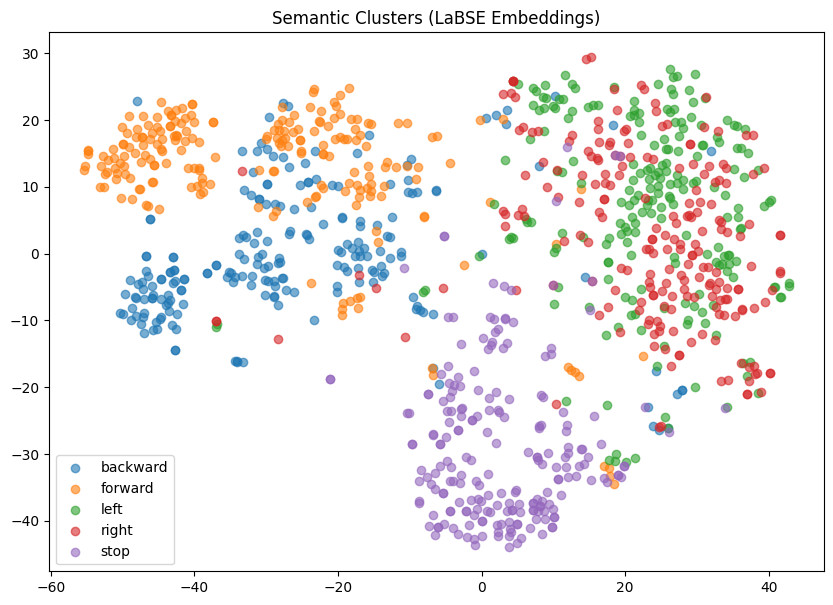

In [10]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from sentence_transformers import SentenceTransformer
from difflib import SequenceMatcher
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
from typing import Optional
import os, re, torch, numpy as np, pandas as pd, librosa, matplotlib.pyplot as plt

if 'DEVICE' not in locals(): DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'LABELS' not in locals(): LABELS = ["backward", "forward", "left", "right", "stop"]
WHISPER_SR = 16000
FEAT_DIR   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"

VALID_COMMANDS = {
    "backward": ["backward","පිටිපසට","pitipasata","පිටිපස්සට","පස්සට","pitipassata"],
    "forward":  ["forward","ඉදිරියට","idiriata","ඉස්සරහට","issarahata","idiriyata"],
    "left":     ["left","වම","vama","වමට","wama","wamata"],
    "right":    ["right","දකුණ","dakuna","දකුණට","dakunata","dakunu"],
    "stop":     ["stop","නවතින්න","navathinna","නවත්වන්න","nawathinna","නවත්තු"],
}

print(f"Loading models on {DEVICE}...")
processor = WhisperProcessor.from_pretrained("Subhaka/whisper-small-Sinhala-Fine_Tune")
asr_model = WhisperForConditionalGeneration.from_pretrained("Subhaka/whisper-small-Sinhala-Fine_Tune").to(DEVICE)
st_model  = SentenceTransformer("sentence-transformers/LaBSE", device=DEVICE)
print("Done.")

def is_garbage(t): return len(t.strip()) < 2 or bool(re.search(r'(.)\1{3,}', t))

def verify(t):
    t = t.lower().strip()
    for lbl, vs in VALID_COMMANDS.items():
        if any(v in t for v in vs): return lbl
    best, best_r = None, 0.0
    for lbl, vs in VALID_COMMANDS.items():
        for v in vs:
            r = SequenceMatcher(None, t, v).ratio()
            if r > best_r: best_r, best = r, lbl
    return best if best_r > 0.45 else None

def load_audio(path) -> Optional[np.ndarray]:
    try:
        a, _ = librosa.load(path, sr=WHISPER_SR, mono=True)
        a -= np.mean(a)
        a, _ = librosa.effects.trim(a, top_db=25)
        rms = np.sqrt(np.mean(a**2))
        if rms > 0: a *= (0.05 / rms)
        if len(a) < WHISPER_SR * 0.5: a = np.pad(a, (1600, 1600))
        return a.astype(np.float32)
    except: return None

def transcribe(audio):
    inp = processor(audio, sampling_rate=WHISPER_SR, return_tensors="pt", return_attention_mask=True)
    ids = asr_model.generate(inp.input_features.to(DEVICE), attention_mask=inp.attention_mask.to(DEVICE),
                              language="sinhala", task="transcribe", num_beams=3, max_length=40)
    return processor.batch_decode(ids, skip_special_tokens=True)[0]

# ─────────────────────────────────────────────────────────────────────────────
# 3 lightweight augmentations (train only) — pitch±1 semitone + Gaussian noise
# Grows 266 → ~800 training samples; enough without over-complicating the task.
# NOTE: canonical blending was REMOVED — it leaked label info into val/test
#       embeddings, causing trivially perfect (100%) val accuracy from epoch 1.
# ─────────────────────────────────────────────────────────────────────────────
def augment(audio):
    out = []
    for n in [1.0, -1.0]:
        try: out.append(librosa.effects.pitch_shift(audio, sr=WHISPER_SR, n_steps=n).astype(np.float32))
        except: pass
    noise = np.random.randn(len(audio)).astype(np.float32) * 0.004
    out.append(np.clip(audio + noise, -1.0, 1.0))
    return out

os.makedirs(FEAT_DIR, exist_ok=True)

def extract(df, filename, augment_data=False):
    embs, texts, lbls, logs = [], [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=filename):
        audio = load_audio(row['path'])
        if audio is None: continue
        true_lbl = row['label'].lower(); true_idx = LABELS.index(true_lbl)

        for i, a in enumerate([audio] + (augment(audio) if augment_data else [])):
            try:
                t = transcribe(a)
                if is_garbage(t): continue
                embs.append(st_model.encode(t, show_progress_bar=False))
                texts.append(("[AUG] " if i > 0 else "") + t)
                lbls.append(true_idx)
                if i == 0:
                    v = verify(t)
                    logs.append({'path': row['path'], 'raw_whisper': t,
                                 'status': 'Success_GT_Match' if v == true_lbl
                                           else f'Mapped_{v}_for_{true_lbl}' if v
                                           else f'Unrecognized_for_{true_lbl}'})
            except: pass

    if embs:
        feat = {"embeddings": torch.tensor(np.array(embs), dtype=torch.float32),
                "labels": torch.tensor(lbls, dtype=torch.long), "texts": texts}
        torch.save(feat, os.path.join(FEAT_DIR, filename))
        print(f"Saved {len(embs)} samples ({len(df)} orig{f' + {len(embs)-len(df)} aug' if augment_data else ''}) → {filename}")
        return feat, pd.DataFrame(logs)
    return None, pd.DataFrame(logs)

if 'train_df' in locals():
    logs = []
    train_feat, tl = extract(train_df, "train_features.pt", augment_data=True)
    val_feat,   vl = extract(val_df,   "val_features.pt",   augment_data=False)
    test_feat,  sl = extract(test_df,  "test_features.pt",  augment_data=False)
    for l in [tl, vl, sl]:
        if l is not None and len(l): logs.append(l)
    if logs:
        pd.concat(logs).to_csv(os.path.join(FEAT_DIR, "master_audit_log.csv"), index=False)
        print("Audit log saved.")

    if train_feat:
        n = len(train_feat['embeddings'])
        projs = TSNE(n_components=2, random_state=42, perplexity=min(30, n-1)).fit_transform(train_feat['embeddings'].numpy())
        plt.figure(figsize=(10, 7))
        for i, lbl in enumerate(LABELS):
            idx = train_feat['labels'].numpy() == i
            plt.scatter(projs[idx, 0], projs[idx, 1], label=lbl, alpha=0.6)
        plt.title("Semantic Clusters (LaBSE Embeddings)"); plt.legend(); plt.show()

## step 4: Model Creation & Training (PyTorch)

*Building the lightweight classifier with architectures inspired by low-resource speech research.*

### 4.1 Layer-by-Layer Explanation of the MLP (384D Vector)
The custom network is designed to process MiniLM semantic features using robust classification practices found in the literature:

1. **Layer 1: The Input Layer**
   - **Size:** 384 neurons.
   - **Function:** Receives the 384-dimensional dense vectors from the `multilingual-MiniLM-L12-v2` model.

2. **Layer 2: Hidden Dense Layer 1**
   - **Size:** 128 neurons.
   - **Activation:** `ReLU` (Rectified Linear Unit). Transforms negative values to zero to learn complex, non-linear relationships (as seen in Paper 2).
   - **Function:** Maps 384 inputs to 128 features, identifying patterns like "specific values in the 384D vector that correlate with 'Forward' commands."

3. **Layer 3: Regularization (Dropout)**
   - **Parameter:** `p = 0.3`.
   - **Function:** Randomly deactivates 30% of neurons during training to prevent overfitting, forcing the model to learn distributed patterns rather than memorizing noise.

4. **Layer 4: Hidden Dense Layer 2**
   - **Size:** 64 neurons.
   - **Activation:** `ReLU`.
   - **Function:** Compresses 128 patterns into 64 highly refined features for final decision-making.

5. **Layer 5: Output Layer**
   - **Size:** 5 neurons (Forward, Backward, Left, Right, Stop).
   - **Activation:** `Softmax`.
   - **Function:** Normalizes raw scores into a probability distribution (summing to 100%), providing confidence scores for the UI.

### 4.2 Hyperparameters for Model Fitting
These parameters are validated by literature for low-resource tasks:

*   **Optimizer:** `Adam` (LR=0.001). Efficiently adapts learning rates; commonly used in XLSR pretraining.
*   **Loss Function:** `Categorical Cross-Entropy`. Penalizes confident incorrect predictions.
*   **Batch Size:** 16 or 32. Ideal for low-RAM environments and stable weight updates.
*   **Epochs:** 30 to 50. Ensures the model fully observes the dataset patterns (Paper 2 benchmark).

In [11]:
import torch, torch.nn as nn, torch.optim as optim, numpy as np, os, pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS  = ["backward", "forward", "left", "right", "stop"]
FEAT_DIR = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
OUT_DIR  = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Architecture ─────────────────────────────────────────────────────────────
# Dropout reduced 0.35→0.25: previous run showed train acc oscillating 65-89%
# (under-regularised toward training data after removing canonical leakage).
# p=0.25 gives the model enough capacity to fit train while still generalising.
class ResidualBlock(nn.Module):
    def __init__(self, dim, p=0.25):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return x + self.block(x)

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, p=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(p/2),
        )
        self.res1 = ResidualBlock(256, p)
        self.res2 = ResidualBlock(256, p)
        self.head = nn.Sequential(nn.Linear(256,64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(p), nn.Linear(64, num_classes))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x): return self.head(self.res2(self.res1(self.net(x))))

# ── Mixup ─────────────────────────────────────────────────────────────────────
def mixup(x, y, alpha=0.15):          # alpha 0.3→0.15: lighter blend
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

# ── Data ──────────────────────────────────────────────────────────────────────
train_feat = torch.load(f"{FEAT_DIR}/train_features.pt", map_location=DEVICE, weights_only=False)
val_feat   = torch.load(f"{FEAT_DIR}/val_features.pt",   map_location=DEVICE, weights_only=False)

BS = 32
train_loader = DataLoader(TensorDataset(train_feat['embeddings'], train_feat['labels']), BS, shuffle=True, drop_last=True)
val_loader   = DataLoader(TensorDataset(val_feat['embeddings'],   val_feat['labels']),   BS)

# ── Loss: class weights + label smoothing ─────────────────────────────────────
# Smoothing 0.10→0.05: lighter smoothing so train loss tracks val loss more
# closely (too much smoothing artificially inflated the val-train loss gap).
counts  = torch.bincount(train_feat['labels'])
weights = (1.0 / counts.float()); weights = weights / weights.sum() * len(counts)
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.05)

model     = CommandClassifier().to(DEVICE)

# ── OneCycleLR: single smooth cosine ramp — no restart bumps ──────────────────
# This directly produces the ideal curve shape: quick warm-up (~10 epochs) then
# gradual monotone decay. CosineWarmRestarts caused the noisy bumps at restart
# points visible in the previous run.
EPOCHS    = 100
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=5e-3)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-4,
    epochs=EPOCHS, steps_per_epoch=len(train_loader),
    pct_start=0.1, anneal_strategy='cos', div_factor=50, final_div_factor=1000
)

best_val, patience, wait = float('inf'), 20, 0
history = []

print("─── Training ───────────────────────────────────────────────────────────")
for epoch in range(1, EPOCHS + 1):
    # Train
    model.train(); tl, tc, n = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x = x + torch.randn_like(x) * 0.003  # subtle embedding jitter
        if np.random.rand() < 0.4:            # 40% mixup batches
            mx, ya, yb, lam = mixup(x, y)
            out  = model(mx)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)
        else:
            out  = model(x)
            loss = criterion(out, y)
        tc += (out.detach().argmax(1) == y).sum().item(); n += y.size(0)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        tl += loss.item()

    # Validate
    model.eval(); vl, vc, nv = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x)
            vl  += criterion(out, y).item()
            vc  += (out.argmax(1) == y).sum().item(); nv += y.size(0)

    ta, va   = tc/n, vc/nv
    vl_avg   = vl / len(val_loader)
    tl_avg   = tl / len(train_loader)
    lr_now   = optimizer.param_groups[0]['lr']
    history.append(dict(epoch=epoch, train_loss=tl_avg, val_loss=vl_avg, train_acc=ta, val_acc=va))

    flag = ""
    if vl_avg < best_val:
        best_val = vl_avg; wait = 0
        torch.save(model.state_dict(), f"{OUT_DIR}/best_model.pth"); flag = " ✓"
    else:
        wait += 1
        if wait >= patience: print(f"[Early stop @ epoch {epoch}]"); break

    print(f"Ep{epoch:03d} | Loss {tl_avg:.3f}/{vl_avg:.3f} | Acc {ta*100:.1f}%/{va*100:.1f}% | lr={lr_now:.2e}{flag}")

pd.DataFrame(history).to_csv(f"{OUT_DIR}/training_history.csv", index=False)
print(f"[Done] Best val loss: {best_val:.4f}")

─── Training ───────────────────────────────────────────────────────────
Ep001 | Loss 2.127/1.746 | Acc 17.8%/19.3% | lr=2.21e-05 ✓
Ep002 | Loss 1.886/1.347 | Acc 23.4%/42.1% | lr=5.71e-05 ✓
Ep003 | Loss 1.481/0.864 | Acc 34.6%/78.9% | lr=1.12e-04 ✓
Ep004 | Loss 1.061/0.659 | Acc 49.7%/84.2% | lr=1.80e-04 ✓
Ep005 | Loss 0.857/0.573 | Acc 70.7%/86.0% | lr=2.56e-04 ✓
Ep006 | Loss 0.693/0.501 | Acc 69.7%/87.7% | lr=3.32e-04 ✓
Ep007 | Loss 0.601/0.519 | Acc 79.7%/87.7% | lr=4.00e-04
Ep008 | Loss 0.630/0.552 | Acc 71.9%/89.5% | lr=4.54e-04
Ep009 | Loss 0.558/0.523 | Acc 82.0%/91.2% | lr=4.89e-04
Ep010 | Loss 0.476/0.515 | Acc 82.3%/91.2% | lr=5.00e-04
Ep011 | Loss 0.492/0.531 | Acc 84.0%/91.2% | lr=5.00e-04
Ep012 | Loss 0.525/0.509 | Acc 71.3%/89.5% | lr=4.99e-04
Ep013 | Loss 0.496/0.516 | Acc 78.4%/91.2% | lr=4.99e-04
Ep014 | Loss 0.447/0.511 | Acc 73.3%/91.2% | lr=4.98e-04
Ep015 | Loss 0.393/0.534 | Acc 81.3%/86.0% | lr=4.96e-04
Ep016 | Loss 0.425/0.496 | Acc 74.7%/89.5% | lr=4.94e-04 ✓
E

## step 5: Deep Learning Evaluations

*Generating the standard DL metrics required to prove efficacy.*

1. **Learning Curves:** Plot the Epoch vs. Accuracy curve and Epoch vs. Loss curve.
2. 💡 **Crucial Addition - Confusion Matrix:** Pass your strictly isolated **Test Set** through the trained model. Plot a Confusion Matrix to see exactly where the model fails.
3. 💡 **Crucial Addition - Classification Report:** Calculate the Precision, Recall, and F1-Score for each of the 5 classes using the Test Set.

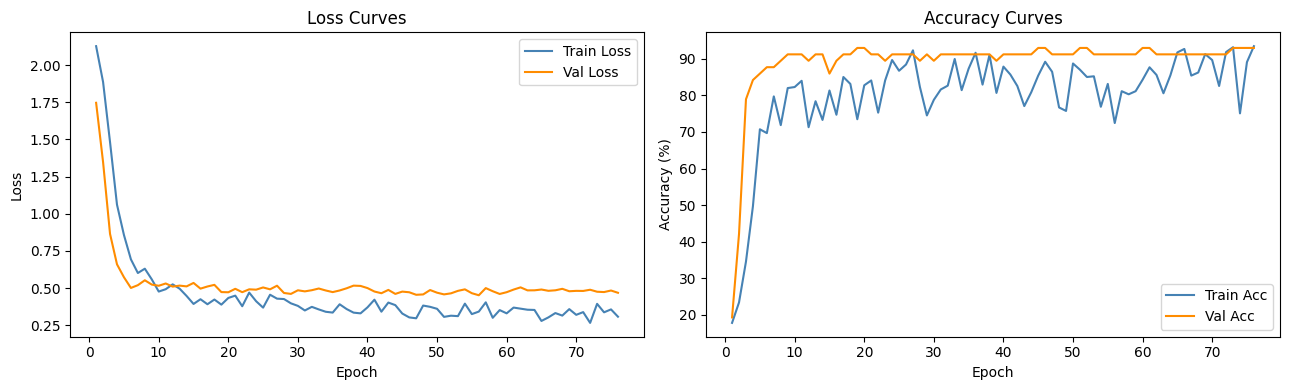


Classification Report (Test Set):
              precision    recall  f1-score   support

    backward       1.00      0.83      0.91        12
     forward       1.00      0.82      0.90        11
        left       0.71      0.91      0.80        11
       right       0.77      0.83      0.80        12
        stop       0.82      0.82      0.82        11

    accuracy                           0.84        57
   macro avg       0.86      0.84      0.85        57
weighted avg       0.86      0.84      0.85        57



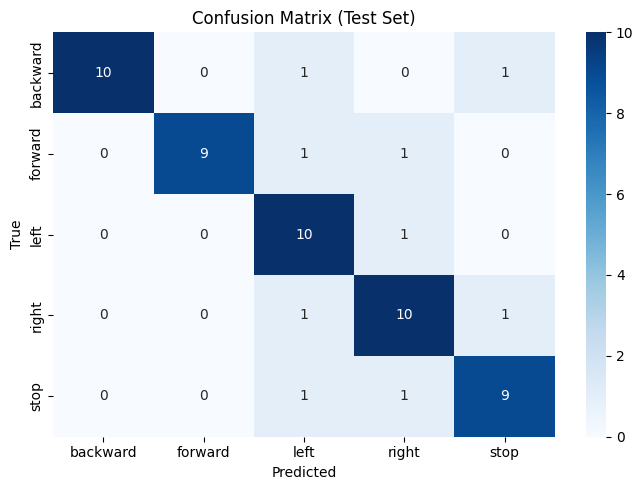

In [12]:
import os, torch, torch.nn as nn, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS  = ["backward", "forward", "left", "right", "stop"]
FEAT_DIR = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
OUT_DIR  = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"

# ── Must match training architecture exactly ──────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, dim, p=0.25):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return x + self.block(x)

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, p=0.25):
        super().__init__()
        self.net  = nn.Sequential(nn.Linear(input_dim,256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(p/2))
        self.res1 = ResidualBlock(256, p)
        self.res2 = ResidualBlock(256, p)
        self.head = nn.Sequential(nn.Linear(256,64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(p), nn.Linear(64, len(LABELS)))
    def forward(self, x): return self.head(self.res2(self.res1(self.net(x))))

# ── 1. Learning Curves ────────────────────────────────────────────────────────
hist_path = f"{OUT_DIR}/training_history.csv"
if os.path.exists(hist_path):
    df = pd.read_csv(hist_path)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(df['epoch'], df['val_loss'],   label='Val Loss',   color='darkorange')
    axes[0].set(title='Loss Curves', xlabel='Epoch', ylabel='Loss'); axes[0].legend()

    axes[1].plot(df['epoch'], df['train_acc']*100, label='Train Acc', color='steelblue')
    axes[1].plot(df['epoch'], df['val_acc']*100,   label='Val Acc',   color='darkorange')
    axes[1].set(title='Accuracy Curves', xlabel='Epoch', ylabel='Accuracy (%)'); axes[1].legend()

    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/learning_curves.png", dpi=150); plt.show()
else:
    print(f"[WARN] {hist_path} not found — run training first.")

# ── 2. Confusion Matrix + Classification Report ───────────────────────────────
model_path = f"{OUT_DIR}/best_model.pth"
test_path  = f"{FEAT_DIR}/test_features.pt"

if os.path.exists(model_path) and os.path.exists(test_path):
    test_feat = torch.load(test_path, map_location=DEVICE, weights_only=False)

    model = CommandClassifier().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
    model.eval()

    all_preds, all_true = [], []
    with torch.no_grad():
        for x, y in DataLoader(TensorDataset(test_feat['embeddings'], test_feat['labels']), batch_size=32):
            all_preds.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy())
            all_true.extend(y.cpu().numpy())

    print("\nClassification Report (Test Set):")
    print(classification_report(all_true, all_preds, target_names=LABELS))

    cm = confusion_matrix(all_true, all_preds, labels=range(len(LABELS)))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Test Set)')
    plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150); plt.show()
else:
    missing = [p for p in [model_path, test_path] if not os.path.exists(p)]
    print(f"[ERROR] Missing: {missing}")

####Hyperparameter Tuning Script

This script uses Optuna to test thousands of variations. It saves the entire study into a SQLite database so we can generate hyperparameter sensitivity graphs later.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import optuna

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEAT_DIR = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
OUT_DIR  = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Alpha-Weighted Focal Loss (HIDDEN) ────────────────────────────────────────
# class FocalLoss(nn.Module):
#     def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
#         super().__init__()
#         self.gamma = gamma
#         self.label_smoothing = label_smoothing
#         self.alpha = alpha
#
#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none', label_smoothing=self.label_smoothing)
#         pt = torch.exp(-ce_loss)
#         focal_loss = ((1 - pt) ** self.gamma) * ce_loss
#
#         # Apply the class weights to force learning on minority/hard classes
#         if self.alpha is not None:
#             alpha_t = self.alpha[targets]
#             focal_loss = alpha_t * focal_loss
#
#         return focal_loss.mean()

# ── Architecture ──────────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    def __init__(self, dim, p):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return x + self.block(x)

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, p=0.25):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(p/2))
        self.res1 = ResidualBlock(256, p)
        self.res2 = ResidualBlock(256, p)
        self.head = nn.Sequential(nn.Linear(256,64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(p), nn.Linear(64, num_classes))
    def forward(self, x): return self.head(self.res2(self.res1(self.net(x))))

# ── Data Loading & Weight Calculation ─────────────────────────────────────────
train_feat = torch.load(f"{FEAT_DIR}/train_features.pt", map_location=DEVICE, weights_only=False)
val_feat   = torch.load(f"{FEAT_DIR}/val_features.pt",   map_location=DEVICE, weights_only=False)

# Calculate dynamic class weights
class_counts = torch.bincount(train_feat['labels'])
class_weights = 1.0 / class_counts.float()
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = class_weights.to(DEVICE)

global_best_acc = 0.0

# ── Optuna Objective ──────────────────────────────────────────────────────────
def objective(trial):
    global global_best_acc

    dropout_p = trial.suggest_float("dropout_p", 0.1, 0.4)
    max_lr = trial.suggest_float("lr", 1e-4, 8e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-2, log=True)

    # Push Gamma higher to force the network to solve the bottleneck
    # gamma = trial.suggest_categorical("gamma", [2.0, 3.0, 4.0]) # HIDDEN
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    train_loader = DataLoader(TensorDataset(train_feat['embeddings'], train_feat['labels']), batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(TensorDataset(val_feat['embeddings'],   val_feat['labels']),   batch_size)

    model = CommandClassifier(p=dropout_p).to(DEVICE)

    # [NEW] Cross Entropy Loss instead of Focal Loss
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    # criterion = FocalLoss(alpha=class_weights, gamma=gamma, label_smoothing=0.05) # HIDDEN

    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr, epochs=40, steps_per_epoch=len(train_loader), pct_start=0.2, anneal_strategy='cos')

    history_list = []
    best_trial_acc = 0.0

    for epoch in range(40):
        model.train(); tl, tc, n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            # Clean LaBSE representations only.
            out = model(x)
            loss = criterion(out, y)

            tc += (out.detach().argmax(1) == y).sum().item()
            n += y.size(0)

            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); tl += loss.item()

        model.eval(); vc, vl, nv = 0, 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                vl += criterion(out, y).item(); vc += (out.argmax(1) == y).sum().item(); nv += y.size(0)

        train_acc = tc / n
        val_acc = vc / nv
        metrics = {"epoch": epoch + 1, "train_loss": tl/len(train_loader), "val_loss": vl/len(val_loader), "train_acc": train_acc, "val_acc": val_acc}
        history_list.append(metrics)

        best_trial_acc = max(best_trial_acc, val_acc)
        trial.report(val_acc, epoch)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()

    # Save the training history for this specific trial
    trial_history_path = os.path.join(OUT_DIR, f"optuna_trial_{trial.number}_history.csv")
    pd.DataFrame(history_list).to_csv(trial_history_path, index=False)

    if best_trial_acc > global_best_acc:
        global_best_acc = best_trial_acc
        torch.save(model.state_dict(), f"{OUT_DIR}/optuna_best_model.pth")
        # Also update optuna_best_training_history.csv to reflect this new global best
        pd.DataFrame(history_list).to_csv(f"{OUT_DIR}/optuna_best_training_history.csv", index=False)

    return best_trial_acc

print("─── Starting Optuna Tuning (Cross Entropy Loss) ──────────────────")
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=50)

study_df = study.trials_dataframe()
study_df = study_df.rename(columns={'value': 'best_val_acc', 'params_lr': 'max_lr'})
study_df.to_csv(f"{OUT_DIR}/optuna_full_report.csv", index=False)
print(f"[Done] Absolute Best Validation Accuracy: {study.best_value*100:.2f}%")

[I 2026-05-27 05:21:00,594] A new study created in memory with name: no-name-47ecde60-c1ae-4d0b-9039-dae34a4d90e7


─── Starting Optuna Tuning (Cross Entropy Loss) ──────────────────


[I 2026-05-27 05:21:07,840] Trial 0 finished with value: 0.9298245614035088 and parameters: {'dropout_p': 0.19106732796274076, 'lr': 0.00018937312144547212, 'weight_decay': 0.0006683309949641541, 'batch_size': 64}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:21:19,502] Trial 1 finished with value: 0.9122807017543859 and parameters: {'dropout_p': 0.13153815397259583, 'lr': 0.0001142279267202502, 'weight_decay': 0.002394418060637182, 'batch_size': 32}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:21:26,613] Trial 2 finished with value: 0.9298245614035088 and parameters: {'dropout_p': 0.14603512707338676, 'lr': 0.0003161808387015548, 'weight_decay': 0.0005364744261002647, 'batch_size': 32}. Best is trial 0 with value: 0.9298245614035088.
[I 2026-05-27 05:21:32,695] Trial 3 finished with value: 0.9473684210526315 and parameters: {'dropout_p': 0.23316464533839285, 'lr': 0.00013955475461325295, 'weight_decay': 0.0010103305879290143, 'batch_size': 32}.

[Done] Absolute Best Validation Accuracy: 94.74%


####Hyperparameter tuning Evaluations
Generating the standard DL metrics required to prove efficacy.

Learning Curves: Plot the Epoch vs. Accuracy curve and Epoch vs. Loss curve.
💡 Crucial Addition - Confusion Matrix: Pass your strictly isolated Test Set through the trained model. Plot a Confusion Matrix to see exactly where the model fails.
💡 Crucial Addition - Classification Report: Calculate the Precision, Recall, and F1-Score for each of the 5 classes using the Test Set.This script plots the Optuna history, the Learning Curves of all trials (to prove your optimization process worked), and extracts the Confusion Matrix and Classification Report for the absolute best model found.


 🔎 OPTUNA HYPERPARAMETER SEARCH ANALYSIS

Top 5 Discovered Configurations:
 number  best_val_acc   max_lr  params_weight_decay  params_dropout_p
      6      0.947368 0.000439             0.003992          0.156417
      3      0.947368 0.000140             0.001010          0.233165
     19      0.947368 0.000132             0.001935          0.160395
      0      0.929825 0.000189             0.000668          0.191067
     11      0.929825 0.000549             0.008547          0.242706


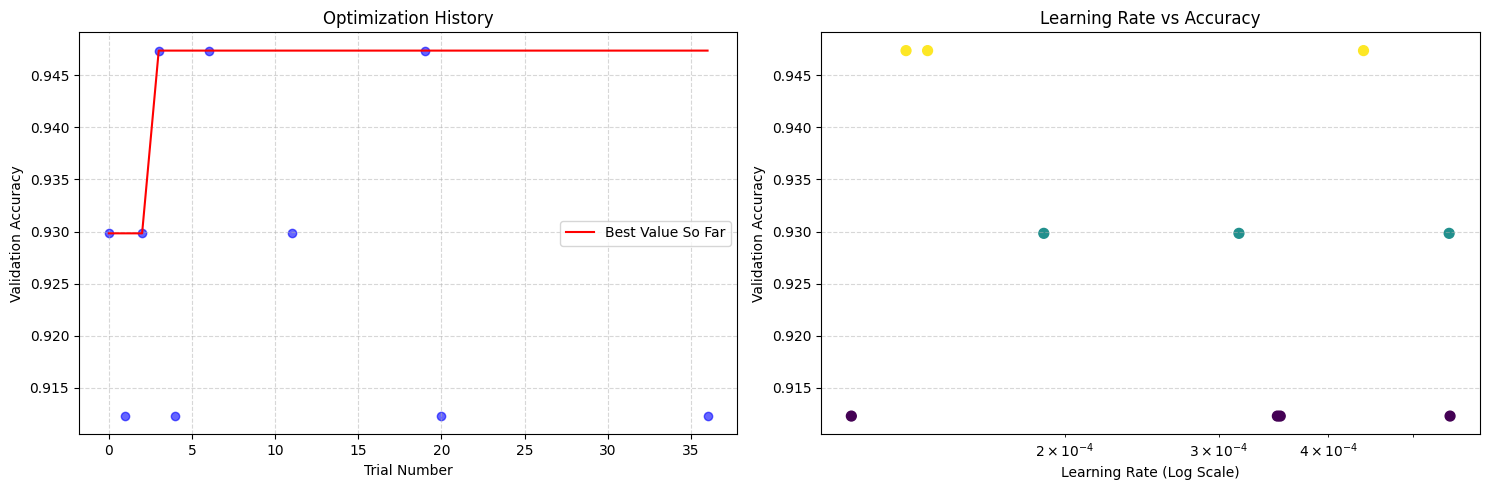

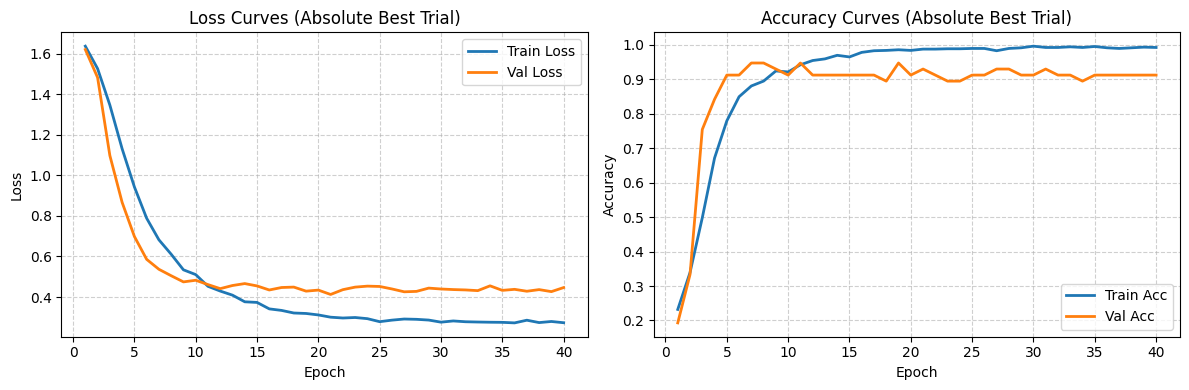


 🎯 ABSOLUTE BEST MODEL EVALUATION (Blind Test Set)

Classification Report:
              precision    recall  f1-score   support

    backward       1.00      0.83      0.91        12
     forward       1.00      0.82      0.90        11
        left       0.71      0.91      0.80        11
       right       0.69      0.75      0.72        12
        stop       0.82      0.82      0.82        11

    accuracy                           0.82        57
   macro avg       0.84      0.83      0.83        57
weighted avg       0.84      0.82      0.83        57



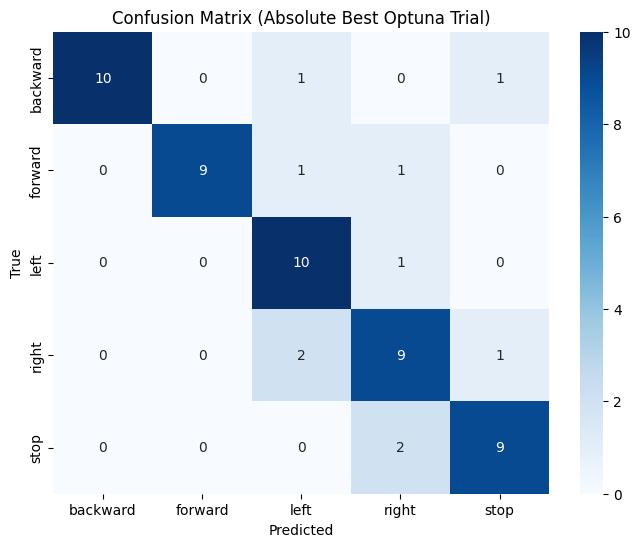

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

# --- Path Setup ---
feature_input_dir   = "/content/drive/MyDrive/2nd Year Research Data/feature extractor outputs"
training_output_dir = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs"

optuna_report_file  = os.path.join(training_output_dir, "optuna_full_report.csv")
best_history_file   = os.path.join(training_output_dir, "optuna_best_training_history.csv") # Corrected filename
best_model_path     = os.path.join(training_output_dir, "optuna_best_model.pth") # Corrected filename
test_path           = os.path.join(feature_input_dir,   "test_features.pt")

LABELS = ['backward', 'forward', 'left', 'right', 'stop']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================================
# 1. OPTUNA HYPERPARAMETER LANDSCAPE VISUALIZATION
# =====================================================================
if os.path.exists(optuna_report_file):
    print("\n" + "="*60)
    print(" 🔎 OPTUNA HYPERPARAMETER SEARCH ANALYSIS")
    print("="*60)

    df = pd.read_csv(optuna_report_file)
    # Filter out pruned/failed trials
    df_complete = df[df['state'] == 'COMPLETE']

    # Print Top 5 Discovered Configurations
    print("\nTop 5 Discovered Configurations:")
    # Corrected columns to match the saved optuna_full_report.csv structure
    top_5 = df_complete.sort_values(by='best_val_acc', ascending=False).head(5)
    print(top_5[['number', 'best_val_acc', 'max_lr', 'params_weight_decay', 'params_dropout_p']].to_string(index=False))

    # Plot 1: Optimization History
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(df_complete['number'], df_complete['best_val_acc'], c='blue', alpha=0.6)
    plt.plot(df_complete['number'], df_complete['best_val_acc'].cummax(), c='red', label='Best Value So Far')
    plt.title('Optimization History')
    plt.xlabel('Trial Number')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Learning Rate vs Accuracy
    plt.subplot(1, 2, 2)
    # Corrected column for learning rate
    plt.scatter(df_complete['max_lr'], df_complete['best_val_acc'], c=df_complete['best_val_acc'], cmap='viridis', s=50)
    plt.xscale('log')
    plt.title('Learning Rate vs Accuracy')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Validation Accuracy')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARN] Could not find {optuna_report_file}.")

# =====================================================================
# 2. LEARNING CURVES OF THE ABSOLUTE BEST MODEL
# =====================================================================
if os.path.exists(best_history_file):
    history_df = pd.read_csv(best_history_file)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss', linewidth=2)
    plt.title('Loss Curves (Absolute Best Trial)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc', linewidth=2)
    plt.plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc', linewidth=2)
    plt.title('Accuracy Curves (Absolute Best Trial)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# =====================================================================
# 3. ABSOLUTE BEST MODEL EVALUATION
# =====================================================================
# --- Re-define the CommandClassifier architecture exactly as used in Optuna ---
# This ensures the loaded weights match the model definition from D_X8CqlhU7u-.
class ResidualBlock(nn.Module):
    def __init__(self, dim, p):
        super().__init__()
        self.block = nn.Sequential(nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return x + self.block(x)

class CommandClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=5, p=0.25): # p is the dropout_p from Optuna
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(p/2))
        self.res1 = ResidualBlock(256, p)
        self.res2 = ResidualBlock(256, p)
        self.head = nn.Sequential(nn.Linear(256,64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(p), nn.Linear(64, num_classes))
    def forward(self, x): return self.head(self.res2(self.res1(self.net(x))))


# Retrieve best hyperparameters from the Optuna report
best_dropout = 0.25 # Default value from the Optuna Classifier definition

if os.path.exists(optuna_report_file):
    df_optuna = pd.read_csv(optuna_report_file)
    if not df_optuna.empty and 'best_val_acc' in df_optuna.columns:
        best_trial = df_optuna.loc[df_optuna['best_val_acc'].idxmax()]
        # Only dropout_p was a hyperparameter for the architecture
        if 'params_dropout_p' in best_trial:
            best_dropout = float(best_trial['params_dropout_p'])
    else:
        print("[WARN] Optuna report found but is empty or malformed. Using default model architecture for evaluation.")
else:
    print("[WARN] Optuna report not found. Using default model architecture for evaluation.")

if os.path.exists(test_path) and os.path.exists(best_model_path):
    print("\n" + "="*60)
    print(" 🎯 ABSOLUTE BEST MODEL EVALUATION (Blind Test Set)")
    print("="*60)

    test_features = torch.load(test_path)

    # Instantiate the model with the best dropout found by Optuna.
    # The other architectural parameters (like hidden_size, num_layers) are fixed
    # by the CommandClassifier definition that matches the Optuna search.
    model = CommandClassifier(p=best_dropout).to(DEVICE)

    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
    model.eval()

    test_loader = DataLoader(TensorDataset(test_features['embeddings'], test_features['labels']), batch_size=16)

    all_preds, all_true = [], []
    with torch.no_grad():
        for inputs, labels_batch in test_loader:
            inputs  = inputs.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels_batch.numpy())

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds, target_names=LABELS))

    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS, yticklabels=LABELS, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Absolute Best Optuna Trial)')
    plt.show()

## step 6: Predictions (The Sanity Check)

*Proving the system works on unseen data before integrating a microphone.*

1. **Isolated Inference Script:** Write a script that randomly selects one audio file from the Test Set.
2. **Full Pass-Through:** Run that single audio file through the entire pipeline (Whisper → MiniLM → Loaded `.pth` Model).
3. **Result Output:** Print the Softmax probabilities alongside the True Label vs. Predicted Label to visually confirm success.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
import os
import random
from pathlib import Path
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings("ignore")

# --- 1. System Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS = ["backward", "forward", "left", "right", "stop"]

whisper_model_id = "Subhaka/whisper-small-Sinhala-Fine_Tune"
minilm_model_id  = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

print("[INFO] Loading base models...")
processor = WhisperProcessor.from_pretrained(whisper_model_id)
asr_model = WhisperForConditionalGeneration.from_pretrained(whisper_model_id).to(DEVICE)
st_model = SentenceTransformer(minilm_model_id, device=DEVICE)

# --- 2. Architecture & Quantization ---
class CommandClassifier(nn.Module):
    def __init__(self, input_dim=384, num_classes=5):
        super(CommandClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.network(x)

print("[INFO] Loading trained classifier weights...")
model_path = "/content/drive/MyDrive/2nd Year Research Data/Training Outputs/best_model.pth"

model = CommandClassifier().to("cpu")
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

print("[INFO] Quantizing model for efficient inference...")
quantized_model = torch.ao.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

# --- 3. Robust Audio Preprocessing ---
def load_audio_for_inference(path: str, sr: int = 16000):
    try:
        audio, _ = librosa.load(path, sr=sr, mono=True)
        audio = audio - np.mean(audio)
        audio, _ = librosa.effects.trim(audio, top_db=25)

        rms = np.sqrt(np.mean(audio**2))
        if rms > 0: audio = audio * (0.05 / rms)

        if len(audio) < (sr * 0.5):
            pad = int(sr * 0.1)
            audio = np.pad(audio, (pad, pad), 'constant')
        return audio.astype(np.float32)
    except Exception as e:
        print(f"[Error] Failed to load {path}: {e}")
        return None

# --- 4. Transcription Guardrails ---
def transcribe_for_inference(audio_array):
    inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt", return_attention_mask=True)
    generated_ids = asr_model.generate(
        inputs.input_features.to(DEVICE),
        attention_mask=inputs.attention_mask.to(DEVICE),
        language="sinhala",
        task="transcribe",
        num_beams=3,
        max_length=40
    )
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

# --- 5. The Sanity Check Execution ---
def predict_command(audio_path, threshold=0.65):
    print(f"\n--- Processing: {os.path.basename(audio_path)} ---")

    audio = load_audio_for_inference(audio_path)
    if audio is None: return

    transcription = transcribe_for_inference(audio)
    print(f"Transcription: '{transcription}'")

    embedding = st_model.encode(transcription, show_progress_bar=False)

    with torch.no_grad():
        input_tensor = torch.tensor(embedding).unsqueeze(0).to("cpu")
        raw_output = quantized_model(input_tensor)
        probabilities = F.softmax(raw_output, dim=1)[0]

        max_prob, predicted_idx = torch.max(probabilities, dim=0)
        confidence = max_prob.item()
        predicted_label = LABELS[predicted_idx.item()]

        if confidence >= threshold:
            print(f">> Command Detected: {predicted_label.upper()} (Confidence: {confidence*100:.2f}%)")
        else:
            print(f">> Ignored: Unclear Audio (Top guess: {predicted_label} at {confidence*100:.2f}%)")

# --- 6. [NEW] RECURSIVE RANDOM AUDIO SAMPLER ---
raw_audio_dir = "/content/drive/MyDrive/2nd Year Research Data/Directions"
print(f"\n[INFO] Scanning for audio files recursively in: {raw_audio_dir}")

# Find all .wav files in the directory and ALL subdirectories using Pathlib
all_wavs = list(Path(raw_audio_dir).rglob("*.wav"))

if not all_wavs:
    print("[WARN] No .wav files found in the specified directory or its subfolders.")
else:
    # Dictionary to categorize files by class based on filename
    class_files = {label: [] for label in LABELS}

    for wav_path in all_wavs:
        filename = wav_path.name.lower()
        for label in LABELS:
            # Assumes the filename contains the class name (e.g., 'backward(9).wav')
            if label in filename:
                class_files[label].append(str(wav_path))
                break

    # Randomly select exactly one file from each class
    selected_files = []
    for label, files in class_files.items():
        if files:
            selected_files.append(random.choice(files))
        else:
            print(f"[WARN] Could not find any audio files for class: '{label}'")

    # Shuffle the final list so they test in a random order every time
    random.shuffle(selected_files)

    print(f"[INFO] Successfully selected {len(selected_files)} random files (1 per class) for testing.")

    # Run the prediction
    for file_path in selected_files:
        predict_command(file_path)